In [17]:
import nidaqmx
import time

import numpy as np
import numpy.typing
from typing import Tuple

import matplotlib.pyplot as plt
from nidaqmx.constants import AcquisitionType, ProductCategory
from nidaqmx.constants import TerminalConfiguration
from nidaqmx.constants import AcquisitionType, READ_ALL_AVAILABLE, LineGrouping, Edge


import scipy as sp

In [67]:
import nidaqmx
from nidaqmx.constants import TerminalConfiguration, AcquisitionType

device_name = "Dev5"
threshold = -0.05
window_size = 4000
rate = 250000

with nidaqmx.Task() as task:
    task.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-5,
        max_val=5
    )

    task.timing.cfg_samp_clk_timing(
        rate=rate,
        sample_mode=AcquisitionType.CONTINUOUS
    )

    triggered_sample = None

    while triggered_sample is None:
        samples = task.read(number_of_samples_per_channel=window_size)
        for s in samples:
            if s <= threshold:
                triggered_sample = s
                break

    print("First sample above 0.2 V:", triggered_sample)

First sample above 0.2 V: -0.13651583021157282


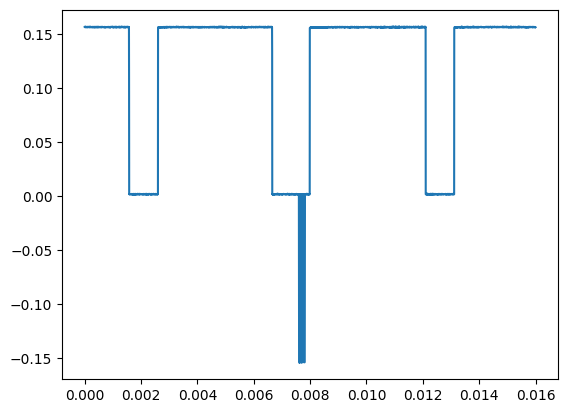

In [68]:
plt.plot(np.linspace(0,window_size/rate, len(samples)),samples)

# Tasks

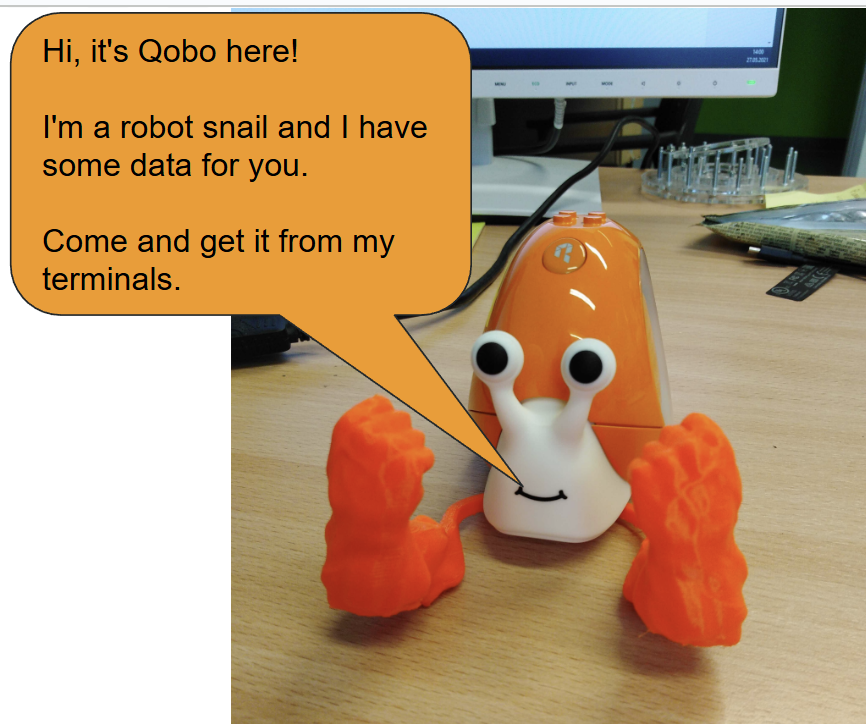

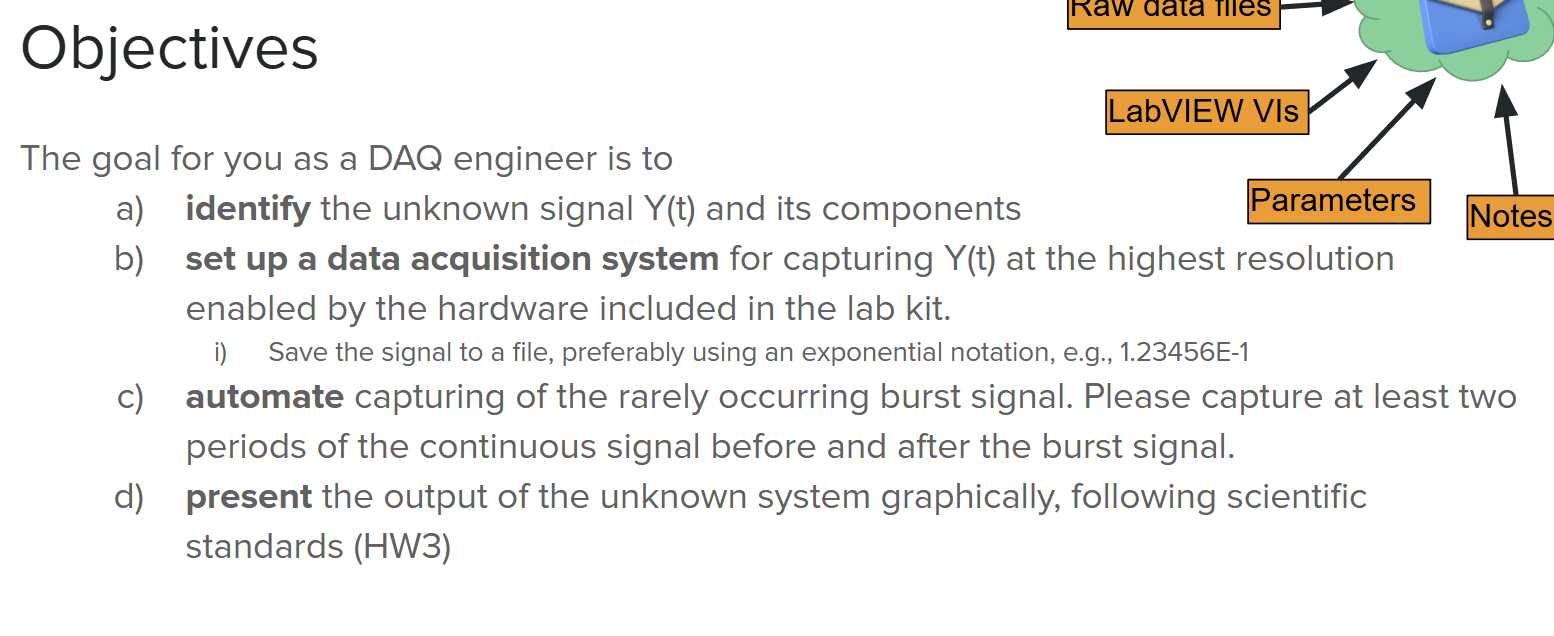